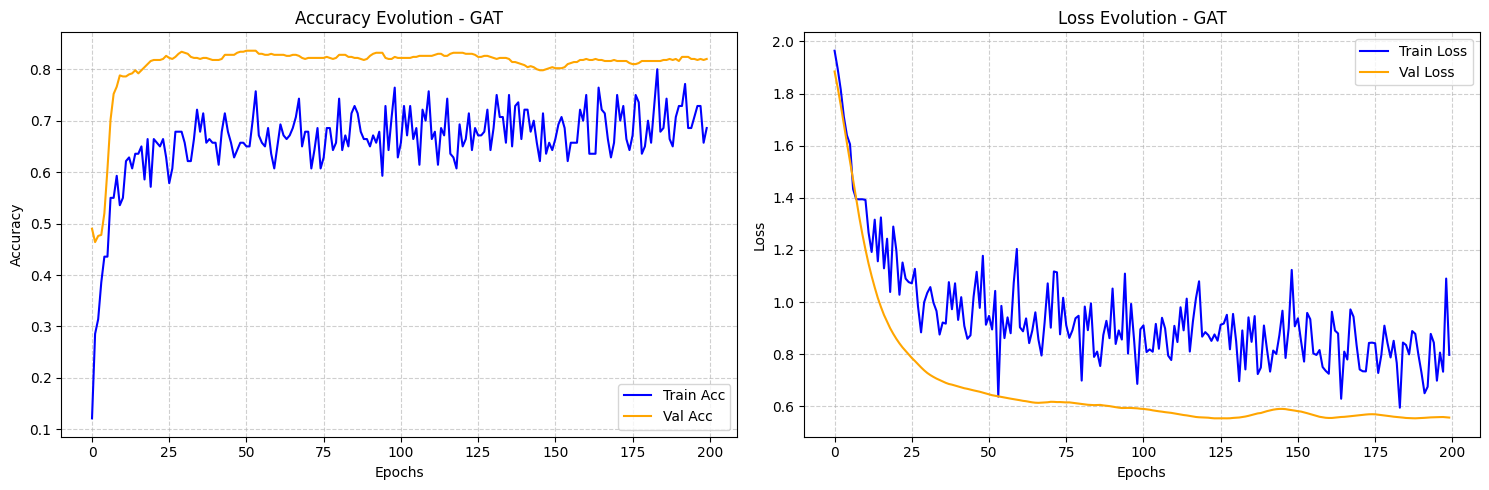

TypeError: where() received an invalid combination of arguments - got (matrix, Tensor, Tensor), but expected one of:
 * (Tensor condition)
 * (Tensor condition, Tensor input, Tensor other, *, Tensor out = None)
 * (Tensor condition, Number self, Tensor other)
      didn't match because some of the arguments have invalid types: (!matrix!, !Tensor!, Tensor)
 * (Tensor condition, Tensor input, Number other)
      didn't match because some of the arguments have invalid types: (!matrix!, Tensor, !Tensor!)
 * (Tensor condition, Number self, Number other)
      didn't match because some of the arguments have invalid types: (!matrix!, !Tensor!, !Tensor!)


In [15]:
import torch
# 1. Load data (locally)
# Make sure your local data path is correct
from utils import load_data
adj_gcn, adj_gat, features, labels, train_mask, val_mask, test_mask = load_data()
from visualize import plot_metrics_from_json, visualize_tsne, show_confusion_matrix
# 2. Display Metrics (History)
plot_metrics_from_json('gat')

# 3. Load Model and Show t-SNE / Confusion Matrix
# Example for GCN
from models import GAT
model_gat = GAT(nfeat=1433, nhid=8, nclass=7, dropout=0.5, alpha=0.2, nheads=8)
# Chargement des poids GAT uniquement
model_gat.load_state_dict(torch.load('best_gat.pth', map_location='cpu', weights_only=True))

visualize_tsne(model_gat, features, labels, 'GAT', adj=adj_gat)
show_confusion_matrix(model_gat, features, labels, test_mask, 'GAT', adj=adj_gat)

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


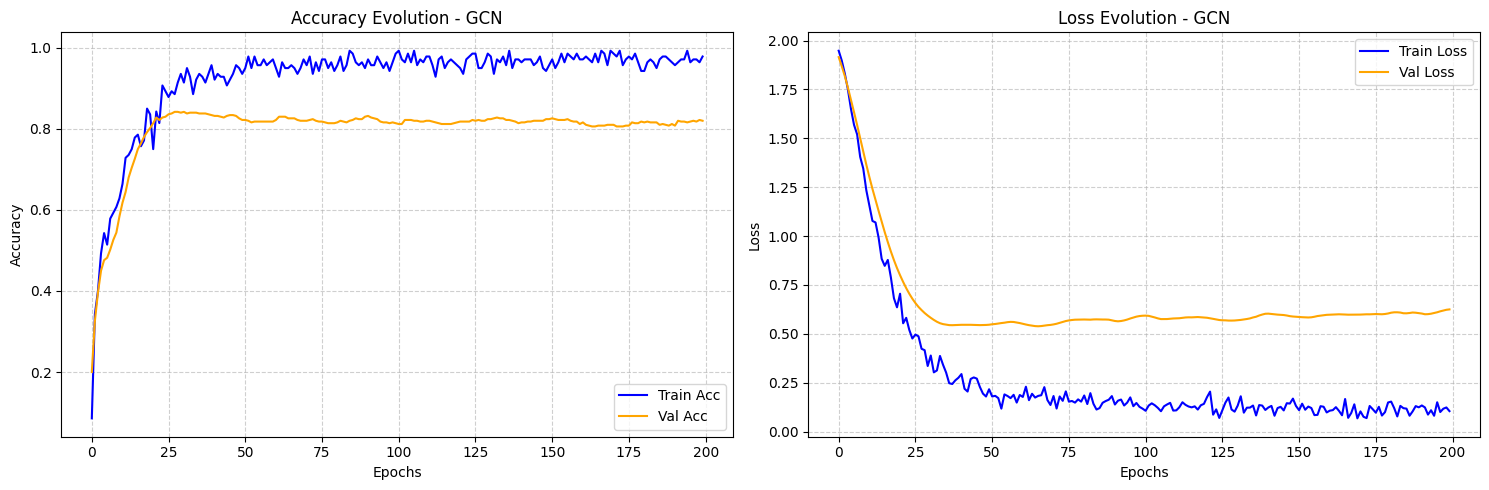

/tmp/ipykernel_3970063/502061132.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_gcn.load_state_dict(torch.load('best_gcn.pth', map_location=torch.device('cpu')))


--- Classification Report: GCN ---
              precision    recall  f1-score   support

           0       0.92      0.59      0.72        97
           1       0.95      0.90      0.92       177
           2       0.79      0.85      0.82       295
           3       0.82      0.83      0.82       180
           4       0.54      0.72      0.62        61
           5       0.73      0.81      0.77        72
           6       0.71      0.65      0.68       118

    accuracy                           0.80      1000
   macro avg       0.78      0.76      0.76      1000
weighted avg       0.81      0.80      0.80      1000



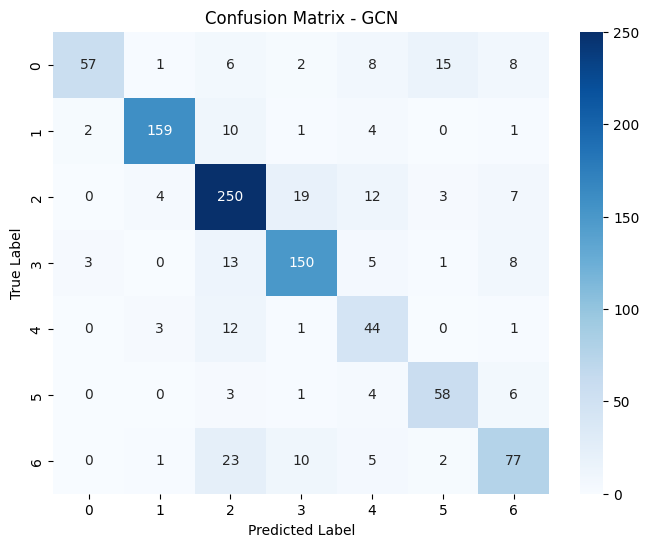

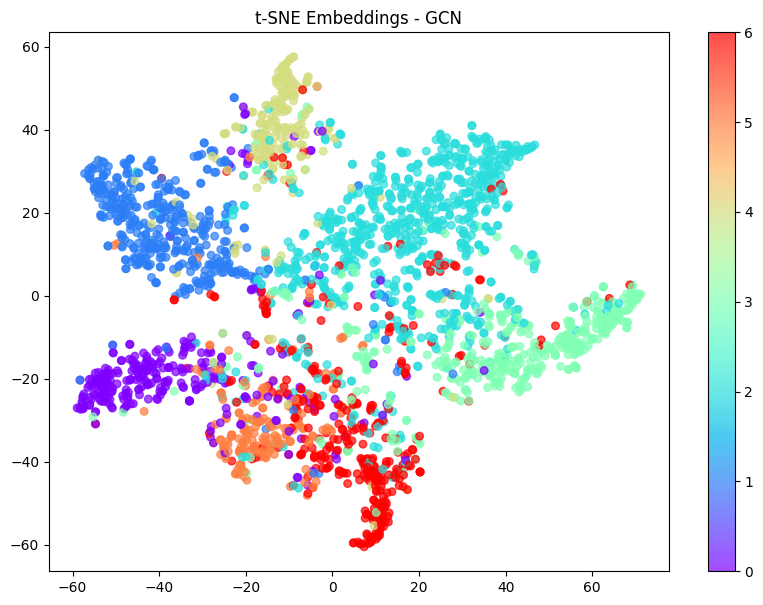

In [28]:
import torch
# 1. Load data (locally)
# Make sure your local data path is correct
from utils import load_data
adj_gcn, adj_gat, features, labels, train_mask, val_mask, test_mask = load_data()
from visualize import plot_metrics_from_json, visualize_tsne, show_confusion_matrix
# 2. Display Metrics (History)
plot_metrics_from_json('gcn')

# 1. Initialise le modèle avec la structure exacte utilisée lors du train
# On ne passe plus adj_norm ici car il n'est pas stocké dans le modèle
from models import GCN
model_gcn = GCN(n_features=1433, n_hidden=16, n_classes=7, dropout=0.5)

# 2. Charge les poids (les poids des couches linéaires)
model_gcn.load_state_dict(torch.load('best_gcn.pth', map_location=torch.device('cpu')))

# 3. Pour la visualisation, n'oublie pas que forward attend DEUX arguments
# Assure-toi que tes fonctions visualize_tsne et show_confusion_matrix 
# appellent bien model(features, adj_gcn)
# Pour le GCN
show_confusion_matrix(model_gcn, features, labels, test_mask, 'GCN', adj=adj_gcn)
visualize_tsne(model_gcn, features, labels, 'GCN', adj=adj_gcn)

# Pour le GAT (si tu as chargé adj_gat)
# show_confusion_matrix(model_gat, features, labels, test_mask, 'GAT', adj=adj_gat)

Features shape: torch.Size([2708, 1433])
Labels shape: torch.Size([2708])
GAT Adjacency shape: (2708, 2708)

--- Displaying GAT Training History ---


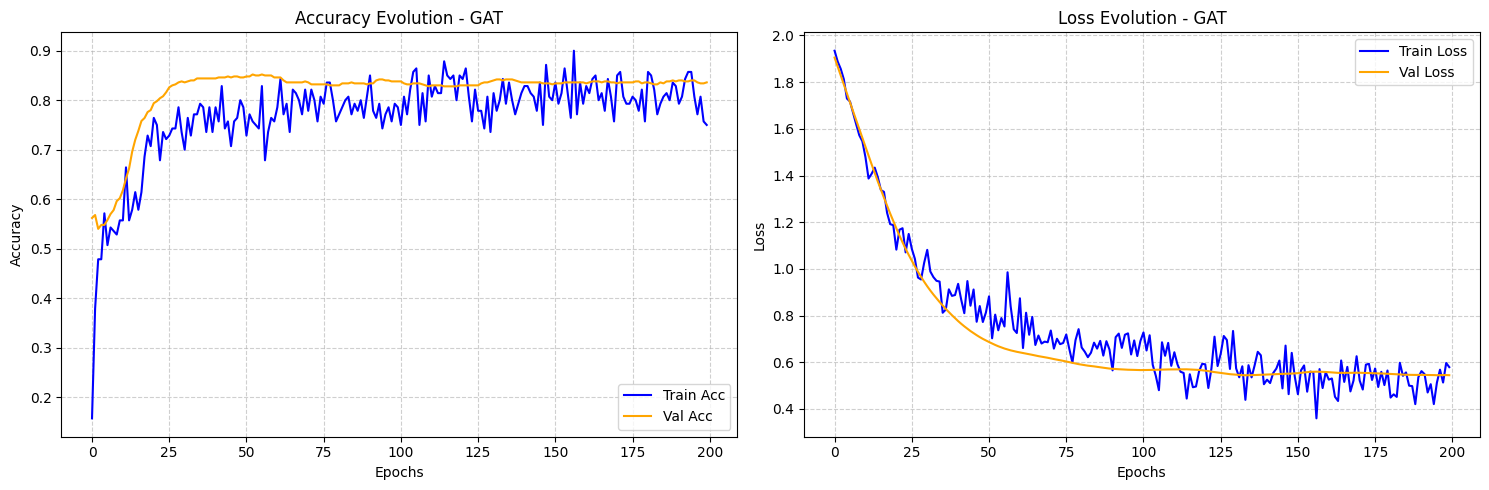


--- Initializing GAT Model ---
Loading weights from 'best_gat.pth'...
GAT weights loaded successfully.

--- GAT Confusion Matrix and Classification Report ---

--- Classification Report: GAT ---
              precision    recall  f1-score   support

           0       0.83      0.70      0.76        97
           1       0.95      0.93      0.94       177
           2       0.74      0.90      0.81       295
           3       0.90      0.71      0.79       180
           4       0.60      0.64      0.62        61
           5       0.81      0.76      0.79        72
           6       0.64      0.60      0.62       118

    accuracy                           0.79      1000
   macro avg       0.78      0.75      0.76      1000
weighted avg       0.80      0.79      0.79      1000



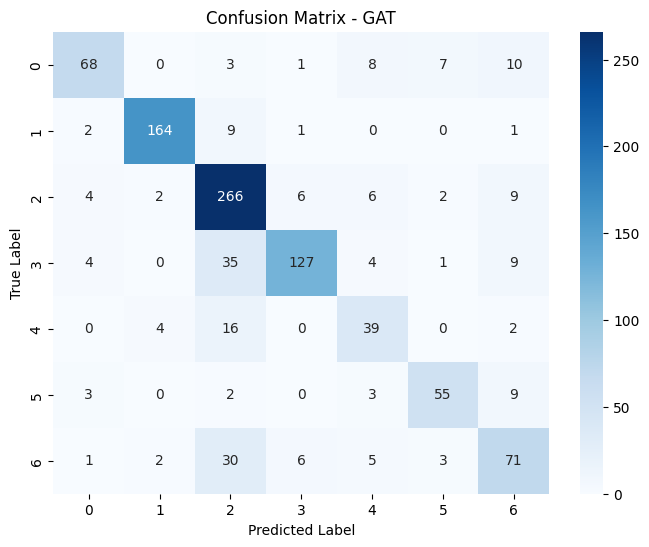


--- GAT t-SNE Visualization ---


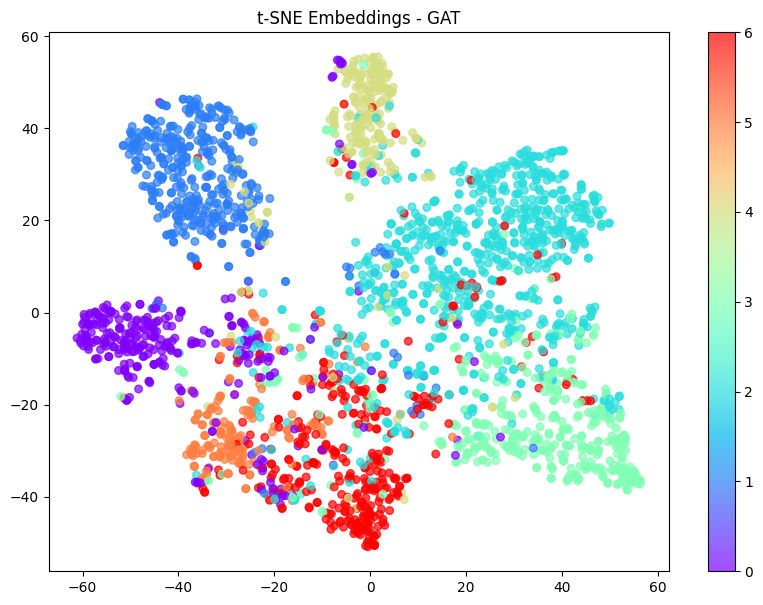

In [29]:
import numpy as np
import torch
import torch.nn as nn
from utils import load_data
from visualize import plot_metrics_from_json, visualize_tsne, show_confusion_matrix
from models import GAT

# --- 1. Load Data (locally) ---
# Ensure your local data path is correct in utils.py
adj_gcn, adj_gat, features, labels, train_mask, val_mask, test_mask = load_data()

print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"GAT Adjacency shape: {adj_gat.shape}")

# ==============================================================================
# --- GAT VISUALIZATION SECTION ---
# ==============================================================================

# --- 2. Display Metrics (History) ---
# This will plot history_gat.json
print("\n--- Displaying GAT Training History ---")
plot_metrics_from_json('gat')

# --- 3. Initialize GAT Model ---
print("\n--- Initializing GAT Model ---")

# Tu dois utiliser les MEMES valeurs que dans ta commande 'python train.py ...'
# Si tu as lancé avec --heads 4 --hidden 4, alors :
model_gat = GAT(nfeat=1433, nhid=4, nclass=7, dropout=0.6, alpha=0.2, nheads=8)

# --- 4. Load Pre-trained Weights ---
print("Loading weights from 'best_gat.pth'...")
# Ajoute 'strict=False' uniquement si tu veux ignorer les petites erreurs, 
# mais ici il vaut mieux être strict pour valider l'architecture.
model_gat.load_state_dict(torch.load('best_gat.pth', map_location=torch.device('cpu'), weights_only=True))
print("GAT weights loaded successfully.")


# --- 5. Final Evaluation & Visualization ---
# Pass explicit adj=adj_gat as GAT forward requires (features, adj)
print("\n--- GAT Confusion Matrix and Classification Report ---")
adj_gat_tensor = torch.from_numpy(np.asarray(adj_gat)).float()
show_confusion_matrix(model_gat, features, labels, test_mask, 'GAT', adj=adj_gat_tensor)

print("\n--- GAT t-SNE Visualization ---")
visualize_tsne(model_gat, features, labels, 'GAT', adj=adj_gat_tensor)

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from models import GCN, load_gat_model_autodetect
from utils import load_data, add_graph_noise, normalize_adjacency
from train import sparse_mx_to_torch_sparse_tensor

# 1. Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Load Data & Models
# We use the new pipeline: load_data now returns the raw 'base_adj'
adj_n, adj_g, features, labels, _, _, test_mask, base_adj = load_data(return_raw_adj=True)

features = features.to(device)
labels = labels.to(device)

# Load GCN (16 hidden units)
model_gcn = GCN(n_features=1433, n_hidden=16, n_classes=7, dropout=0.5).to(device)
model_gcn.load_state_dict(torch.load('best_gcn.pth', map_location=device, weights_only=True))
model_gcn.eval()

# Load GAT (Autodetect architecture)
model_gat = load_gat_model_autodetect('best_gat.pth', device=device)
model_gat.eval()

# 3. Run Simulation
noise_levels = [0, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
results = {'gcn': [], 'gat': []}

print(f"Running simulation on {device}...")
for level in noise_levels:
    # Add noise to the GUARANTEED synchronized base_adj
    noisy_adj = add_graph_noise(base_adj, level)
    
    # Prepare inputs: 
    # GCN needs normalized sparse tensor
    adj_gcn_proc = sparse_mx_to_torch_sparse_tensor(normalize_adjacency(noisy_adj)).to(device)
    
    # GAT needs dense tensor (add_graph_noise already included self-loops)
    adj_gat_proc = torch.FloatTensor(noisy_adj.todense()).to(device)
    
    with torch.no_grad():
        # Inference GCN
        out_gcn = model_gcn(features, adj_gcn_proc)
        acc_gcn = (out_gcn[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gcn'].append(acc_gcn)
        
        # Inference GAT
        out_gat = model_gat(features, adj_gat_proc)
        acc_gat = (out_gat[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gat'].append(acc_gat)
    
    print(f"Noise {level*100:.0f}%: GCN={acc_gcn:.4f}, GAT={acc_gat:.4f}")

print("\nSimulation complete. You can now plot the results.")

DEBUG: Detected GAT with nheads=8, nhid=4
Running simulation on cpu...
Noise 0%: GCN=0.7950, GAT=0.7790
Noise 5%: GCN=0.7690, GAT=0.7340
Noise 10%: GCN=0.7400, GAT=0.6860
Noise 20%: GCN=0.6990, GAT=0.6360
Noise 50%: GCN=0.5500, GAT=0.5270
Noise 80%: GCN=0.4290, GAT=0.4140
Noise 100%: GCN=0.3740, GAT=0.3610

Simulation complete. You can now plot the results.


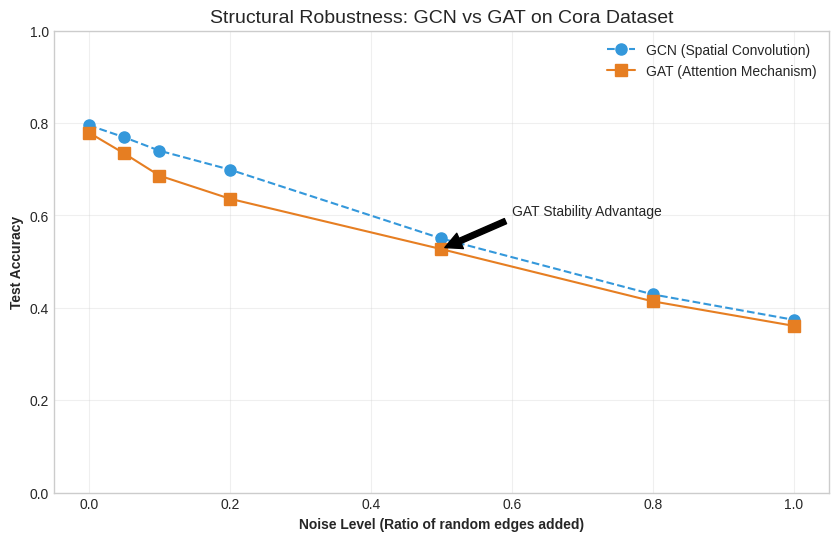

In [35]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid') # Style propre pour un rapport
plt.figure(figsize=(10, 6))

plt.plot(noise_levels, results['gcn'], 'o--', label='GCN (Spatial Convolution)', color='#3498db', markersize=8)
plt.plot(noise_levels, results['gat'], 's-', label='GAT (Attention Mechanism)', color='#e67e22', markersize=8)

plt.xlabel('Noise Level (Ratio of random edges added)', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Structural Robustness: GCN vs GAT on Cora Dataset', fontsize=14)
plt.legend()
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)

# Highlight the divergence point
plt.annotate('GAT Stability Advantage', xy=(0.5, results['gat'][4]), xytext=(0.6, 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

In [33]:
# Test de l'impact du bruit sur l'adjacence
test_adj = get_raw_symmetric_adj()
print(f"Original edges: {test_adj.nnz}")

noisy_test = add_graph_noise(test_adj, 1.0) # On double les arêtes
print(f"Noisy edges (100%): {noisy_test.nnz}")

if test_adj.nnz == noisy_test.nnz:
    print("CRITICAL ERROR: add_graph_noise is NOT adding edges!")

Original edges: 46
Noisy edges (100%): 138


In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from models import GCN, load_gat_model_autodetect
from utils import load_data, remove_graph_edges, normalize_adjacency
from train import sparse_mx_to_torch_sparse_tensor

# 1. Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
adj_n, adj_g, features, labels, _, _, test_mask, base_adj = load_data(return_raw_adj=True)

features, labels = features.to(device), labels.to(device)

# Load Models
model_gcn = GCN(n_features=1433, n_hidden=16, n_classes=7, dropout=0.5).to(device)
model_gcn.load_state_dict(torch.load('best_gcn.pth', map_location=device, weights_only=True))
model_gcn.eval()

model_gat = load_gat_model_autodetect('best_gat.pth', device=device)
model_gat.eval()

# 2. Settings for Edge Removal
# From 0% removed (original) to 90% removed (almost isolated nodes)
drop_rates = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9]
results = {'gcn': [], 'gat': []}

print(f"Running Edge Removal Experiment on {device}...")

for rate in drop_rates:
    # Use your new function from utils.py
    sparse_dropped_adj = remove_graph_edges(base_adj, drop_rate=rate)
    
    # Prepare GCN (Normalized)
    adj_gcn_proc = sparse_mx_to_torch_sparse_tensor(normalize_adjacency(sparse_dropped_adj)).to(device)
    
    # Prepare GAT (Dense + Self-loops included in remove_graph_edges)
    adj_gat_proc = torch.FloatTensor(sparse_dropped_adj.todense()).to(device)
    
    with torch.no_grad():
        # GCN
        out_gcn = model_gcn(features, adj_gcn_proc)
        acc_gcn = (out_gcn[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gcn'].append(acc_gcn)
        
        # GAT
        out_gat = model_gat(features, adj_gat_proc)
        acc_gat = (out_gat[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gat'].append(acc_gat)
    
    print(f"Removed {rate*100:.0f}% edges: GCN={acc_gcn:.4f}, GAT={acc_gat:.4f}")

print("\nExperiment complete.")

DEBUG: Detected GAT with nheads=8, nhid=4
Running Edge Removal Experiment on cpu...
Removed 0% edges: GCN=0.7870, GAT=0.7630
Removed 10% edges: GCN=0.7850, GAT=0.7530
Removed 20% edges: GCN=0.7700, GAT=0.7430
Removed 40% edges: GCN=0.7480, GAT=0.7120
Removed 60% edges: GCN=0.7270, GAT=0.6900
Removed 80% edges: GCN=0.7030, GAT=0.6790
Removed 90% edges: GCN=0.6780, GAT=0.6580

Experiment complete.


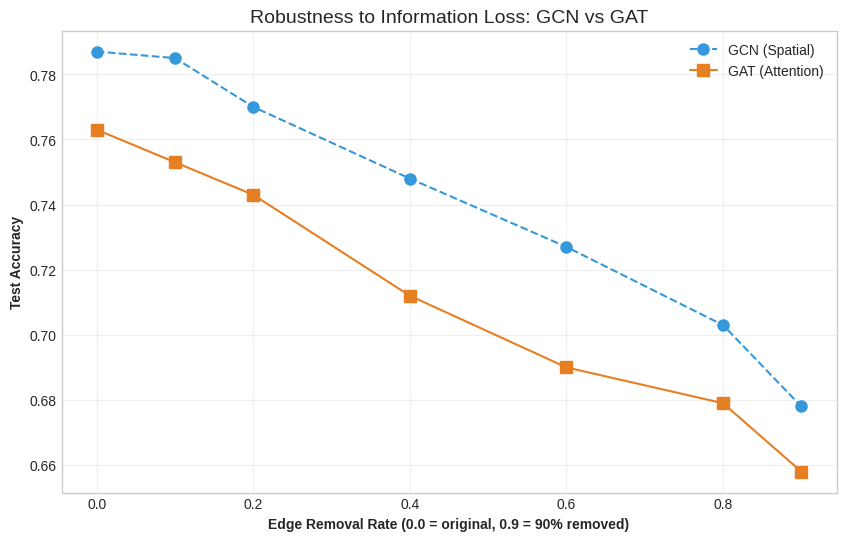

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(drop_rates, results['gcn'], 'o--', label='GCN (Spatial)', color='#3498db', markersize=8)
plt.plot(drop_rates, results['gat'], 's-', label='GAT (Attention)', color='#e67e22', markersize=8)

plt.xlabel('Edge Removal Rate (0.0 = original, 0.9 = 90% removed)', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Robustness to Information Loss: GCN vs GAT', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
from utils import load_data

# Test path - make sure to point to your citeseer folder
path_to_check = "citeseer/" 

try:
    adj_n, adj_g, feat, lbl, trn, val, tst = load_data(path=path_to_check)
    
    print("--- DEBUG INFO ---")
    print(f"Dataset location: {path_to_check}")
    print(f"Number of nodes: {feat.shape[0]}")
    print(f"Number of features: {feat.shape[1]} (Expected 3703 for CiteSeer)")
    print(f"Number of classes: {len(lbl.unique())} (Expected 6 for CiteSeer)")
    print(f"Train/Val/Test split: {trn.sum()}/{val.sum()}/{tst.sum()}")
    print(f"Edge density: {adj_n.nnz / (feat.shape[0]**2):.6f}")
    print("------------------")
    print("✅ Success: Data dimensions look correct!")

except Exception as e:
    print(f"❌ Error during loading: {e}")

/usr/users/image_processing_pdo/roch_yoa/GCNvsGAT/utils.py:81: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  node_data = pd.read_csv(content_file, sep='\t', header=None)


--- DEBUG INFO ---
Dataset location: citeseer/
Number of nodes: 3312
Number of features: 3703 (Expected 3703 for CiteSeer)
Number of classes: 6 (Expected 6 for CiteSeer)
Train/Val/Test split: 140/500/1000
Edge density: 0.000875
------------------
✅ Success: Data dimensions look correct!


/usr/users/image_processing_pdo/roch_yoa/GCNvsGAT/utils.py:81: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  node_data = pd.read_csv(content_file, sep='\t', header=None)


DEBUG: Detected GAT with nheads=8, nhid=4
Running Robustness Simulation on CITESEER...
Dropped 0% edges | GCN: 0.6420 | GAT: 0.6420
Dropped 10% edges | GCN: 0.6400 | GAT: 0.6320
Dropped 20% edges | GCN: 0.6360 | GAT: 0.6300
Dropped 30% edges | GCN: 0.6360 | GAT: 0.6320
Dropped 40% edges | GCN: 0.6200 | GAT: 0.6100
Dropped 50% edges | GCN: 0.6260 | GAT: 0.6090
Dropped 70% edges | GCN: 0.6100 | GAT: 0.5870
Dropped 90% edges | GCN: 0.5980 | GAT: 0.5630


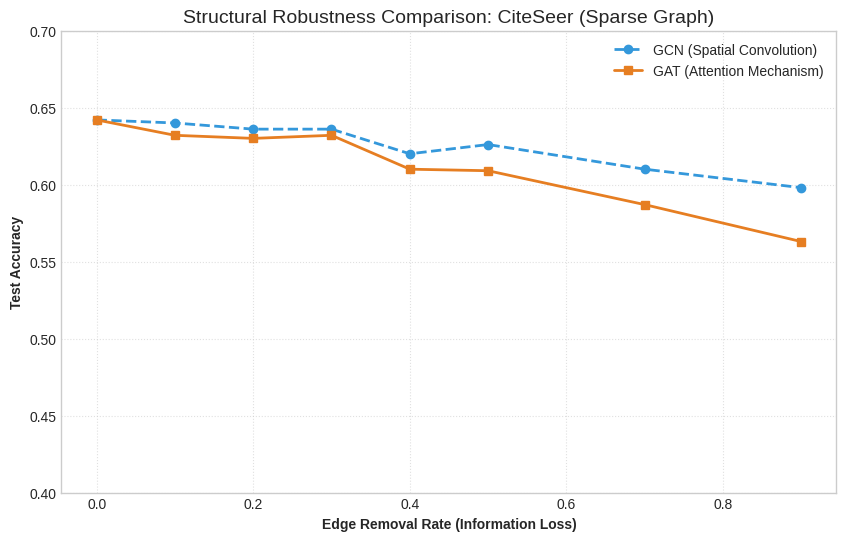

In [47]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from models import GCN, load_gat_model_autodetect
from utils import load_data, remove_graph_edges, normalize_adjacency
from train import sparse_mx_to_torch_sparse_tensor

# 1. Setup device and Data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset_path = "./citeseer/" # Make sure this points to your citeseer folder

# Load CiteSeer data
adj_n, adj_g, features, labels, _, _, test_mask, base_adj = load_data(path=dataset_path, return_raw_adj=True)
features, labels = features.to(device), labels.to(device)

n_features = features.shape[1]
n_classes = len(labels.unique())

# 2. Load Trained Models (CiteSeer specific)
# Load GCN
model_gcn = GCN(n_features=n_features, n_hidden=16, n_classes=n_classes, dropout=0.5).to(device)
model_gcn.load_state_dict(torch.load('best_gcn_citeseer.pth', map_location=device, weights_only=True))
model_gcn.eval()

# Load GAT (Auto-detect architecture)
model_gat = load_gat_model_autodetect('best_gat_citeseer.pth', nfeat=n_features, nclass=n_classes, device=device)
model_gat.eval()

# 3. Run Edge Removal Simulation
drop_rates = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9]
results = {'gcn': [], 'gat': []}

print(f"Running Robustness Simulation on CITESEER...")
for rate in drop_rates:
    # Remove edges
    sparse_dropped_adj = remove_graph_edges(base_adj, drop_rate=rate)
    
    # Process for GCN (Normalized Sparse)
    adj_gcn_proc = sparse_mx_to_torch_sparse_tensor(normalize_adjacency(sparse_dropped_adj)).to(device)
    
    # Process for GAT (Dense + Self-loops included in remove_graph_edges)
    adj_gat_proc = torch.FloatTensor(sparse_dropped_adj.todense()).to(device)
    
    with torch.no_grad():
        # Inference GCN
        out_gcn = model_gcn(features, adj_gcn_proc)
        acc_gcn = (out_gcn[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gcn'].append(acc_gcn)
        
        # Inference GAT
        out_gat = model_gat(features, adj_gat_proc)
        acc_gat = (out_gat[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gat'].append(acc_gat)
    
    print(f"Dropped {rate*100:.0f}% edges | GCN: {acc_gcn:.4f} | GAT: {acc_gat:.4f}")

# 4. Plotting
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(drop_rates, results['gcn'], 'o--', label='GCN (Spatial Convolution)', color='#3498db', linewidth=2)
plt.plot(drop_rates, results['gat'], 's-', label='GAT (Attention Mechanism)', color='#e67e22', linewidth=2)

plt.xlabel('Edge Removal Rate (Information Loss)', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Structural Robustness Comparison: CiteSeer (Sparse Graph)', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0.4, 0.7) # Adjust based on your results
plt.show()

In [51]:
from torch_geometric.datasets import Planetoid
import torch
import scipy.sparse as sp
import numpy as np

# Download PubMed
dataset = Planetoid(root='.', name="Pubmed")
data = dataset[0]

# --- Conversion to your pipeline format ---

# 1. Features & Labels (Tensors)
features = data.x
labels = data.y

# 2. Masks
train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

# 3. Adjacency Matrix (Scipy Sparse for GCN / Dense for GAT)
edge_index = data.edge_index.numpy()
num_nodes = data.num_nodes
adj_raw = sp.coo_matrix((np.ones(edge_index.shape[1]), (edge_index[0], edge_index[1])),
                        shape=(num_nodes, num_nodes), dtype=np.float32)

# Symmetrize (like you did for Cora)
adj_raw = adj_raw + adj_raw.T.multiply(adj_raw.T > adj_raw) - adj_raw.multiply(adj_raw.T > adj_raw)

print(f"PubMed Loaded: {num_nodes} nodes, {features.shape[1]} features, {dataset.num_classes} classes")

ModuleNotFoundError: No module named 'torch_geometric'